In [1]:
!wget -q -O weather_data.csv https://gist.githubusercontent.com/pbeens/736198e988df01611376e500dd6d80bf/raw/weather_data.csv


Row counts by partition:
Partition 0: 3 rows
Partition 1: 5 rows
Partition 2: 4 rows


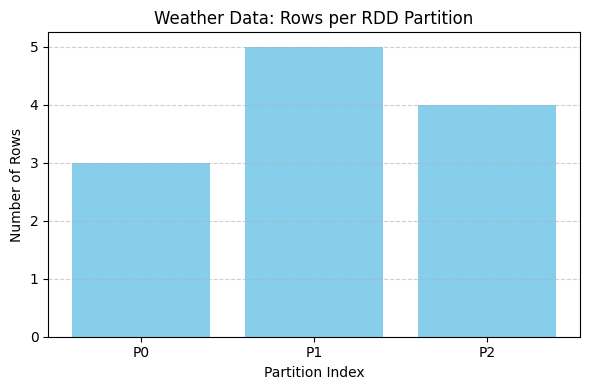

In [5]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

# Start Spark
spark = SparkSession.builder.master("local[*]").appName("ColabWeatherPartition").getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("WARN")

# Load CSV into RDD with 3 partitions
rdd = sc.textFile("weather_data.csv", minPartitions=3)

# Remove header
header = rdd.first()
data_rdd = rdd.filter(lambda row: row != header)

# Count rows per partition
def count_rows(idx, iter):
    yield (idx, sum(1 for _ in iter))

partition_counts = data_rdd.mapPartitionsWithIndex(count_rows).collect()
partition_counts.sort()

# Print partition-wise row counts
print("Row counts by partition:")
for idx, cnt in partition_counts:
    print(f"Partition {idx}: {cnt} rows")

# Prepare bar chart
partition_labels = [f"P{idx}" for idx, _ in partition_counts]
counts = [cnt for _, cnt in partition_counts]

plt.figure(figsize=(6,4))
plt.bar(partition_labels, counts, color='skyblue')
plt.title("Weather Data: Rows per RDD Partition")
plt.xlabel("Partition Index")
plt.ylabel("Number of Rows")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [3]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

# Start Spark
spark = SparkSession.builder.master("local[*]").appName("ConditionWiseCityCount").getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("WARN")

# Load and remove header
rdd = sc.textFile("weather_data.csv")
header = rdd.first()
data_rdd = rdd.filter(lambda row: row != header)

# Parse lines: split by comma → [City, Date, Temp, Humidity, Condition]
parsed_rdd = data_rdd.map(lambda line: line.split(","))

# Extract (condition, city)
condition_city_pairs = parsed_rdd.map(lambda fields: (fields[4].strip(), fields[0].strip()))

# Group by condition, get unique cities, then count
condition_city_count = (
    condition_city_pairs
    .distinct()
    .map(lambda x: (x[0], 1))  # Convert each unique (condition, city) to (condition, 1)
    .reduceByKey(lambda x, y: x + y)
    .collect()
)

# Sort by count descending
condition_city_count.sort(key=lambda x: x[1], reverse=True)

# Print result
print("Condition-wise unique city count:")
for condition, count in condition_city_count:
    print(f"{condition}: {count}")


Condition-wise unique city count:
Sunny: 3
Cloudy: 3
Rain: 2


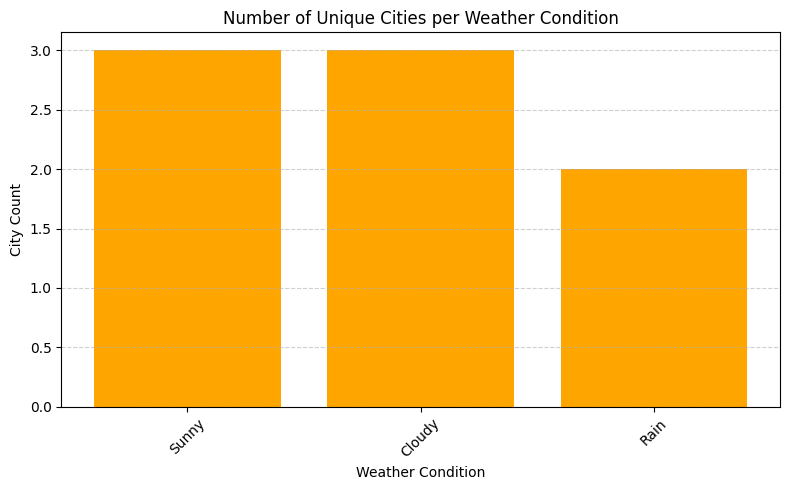

In [4]:
# Separate data for plotting
conditions = [item[0] for item in condition_city_count]
city_counts = [item[1] for item in condition_city_count]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(conditions, city_counts, color='orange')
plt.title("Number of Unique Cities per Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("City Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Group by (Date, Condition) and Count Cities

In [6]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

# Start Spark
spark = SparkSession.builder.master("local[*]").appName("DateConditionCityCount").getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("WARN")

# Load file
rdd = sc.textFile("weather_data.csv")
header = rdd.first()
data_rdd = rdd.filter(lambda row: row != header)

# Parse each line into fields
parsed = data_rdd.map(lambda line: line.split(","))

# Extract ((date, condition), city)
date_condition_city = parsed.map(lambda fields: ((fields[1].strip(), fields[4].strip()), fields[0].strip()))

# Optional: remove duplicate cities for the same (date, condition)
unique_date_condition_city = date_condition_city.distinct()

# Count cities per (date, condition)
grouped_counts = (
    unique_date_condition_city
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda x, y: x + y)
    .collect()
)

# Sort by date
grouped_counts.sort(key=lambda x: x[0])

# Print result
print("City counts grouped by (date, condition):")
for (date, cond), count in grouped_counts:
    print(f"{date} - {cond}: {count}")


City counts grouped by (date, condition):
Calgary - Cloudy: 1
Calgary - Rain: 1
Calgary - Sunny: 1
Halifax - Cloudy: 1
Halifax - Rain: 1
Halifax - Sunny: 1
Toronto - Sunny: 3
Vancouver - Cloudy: 2
Vancouver - Sunny: 1


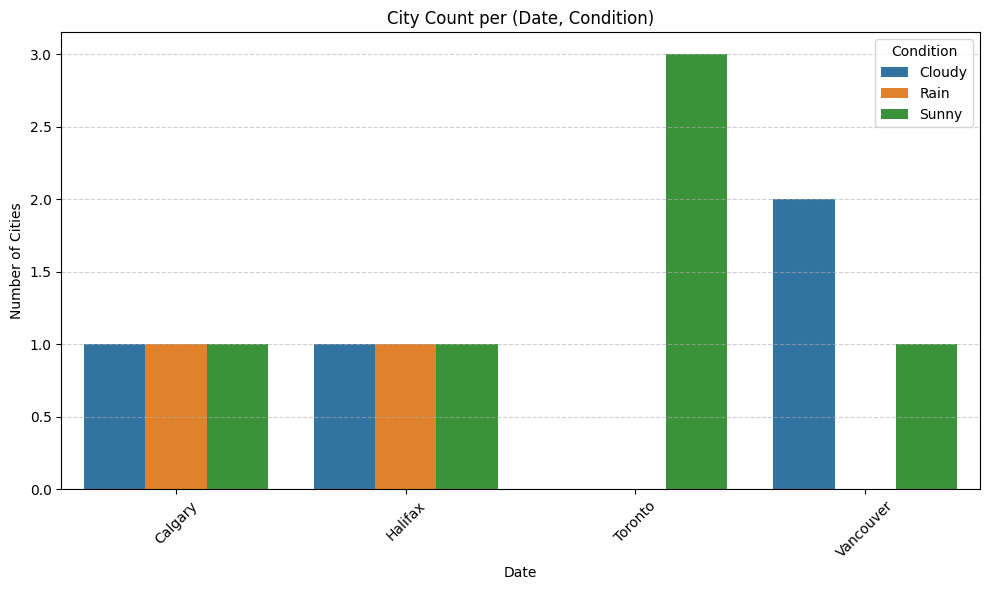

In [7]:
import pandas as pd
import seaborn as sns

# Convert to DataFrame
df = pd.DataFrame(grouped_counts, columns=["date_condition", "count"])
df[['date', 'condition']] = pd.DataFrame(df['date_condition'].tolist(), index=df.index)
df.drop(columns='date_condition', inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='date', y='count', hue='condition')
plt.title("City Count per (Date, Condition)")
plt.xlabel("Date")
plt.ylabel("Number of Cities")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(title="Condition")
plt.show()
